# NALAPRO Final Project Tasks 1 & 2 - Naa Lamiorkor Boye

## Project Tracking, Tools, and References

### Code Repository
GitHub repository: https://github.com/Lamiorkor/NALAPRO_Final_Project

### Experiment Tracking
This project was developed in Google Colab because GPU access was needed for BERT fine-tuning.

Experiment tracking:
- W&B link: https://wandb.ai/naalamiorkor-boye-hochschule-luzern/nalapro-project

### Tools Used
- Google Colab with GPU runtime
- Python
- NumPy, Pandas
- Matplotlib, Seaborn
- Scikit-learn
- NLTK
- Gensim Word2Vec
- PyTorch
- Hugging Face Transformers
- Hugging Face Datasets / Evaluate
- Llama-3
- ChatGPT / AI assistance for debugging, explanation, and structuring code

### AI Use Statement
AI assistance was used to help debug errors, explain concepts, improve code structure, and support interpretation of results. All code was reviewed, adapted, and understood before inclusion.

### Code Sources
Most code was written and adapted by me for this project through vibe coding with ChatGPT. External libraries were used through their official APIs.

## Installing and Importing Libraries and Dataset

In [ ]:
!pip install numpy pandas matplotlib scikit-learn nltk gensim torch transformers datasets accelerate evaluate seaborn wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: naalamiorkor-boye (naalamiorkor-boye-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Core libraries
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')

# Sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Gensim
from gensim.models import Word2Vec

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


from collections import Counter

# Transformers
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import evaluate

from datasets import Dataset

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Preliminary Look at Data

In [ ]:
# Storing the training and testing sets of the data, and setting X and y variables
train_data = fetch_20newsgroups(subset='train')
test_data = fetch_20newsgroups(subset='test')

X_train = train_data.data
y_train = train_data.target

X_test = test_data.data
y_test = test_data.target

In [ ]:
# Displaying key information about the dataset

print("Number of training documents:", len(X_train))
print("Number of test documents:", len(X_test))
print("Number of classes:", len(train_data.target_names))
print("Class names:", train_data.target_names)

Number of training documents: 11314
Number of test documents: 7532
Number of classes: 20
Class names: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [ ]:
# Displaying a sample document from the training set

print("\nSample document:\n")
print(X_train[0])


Sample document:

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [ ]:
print(X_train[1])

From: guykuo@carson.u.washington.edu (Guy Kuo)
Subject: SI Clock Poll - Final Call
Summary: Final call for SI clock reports
Keywords: SI,acceleration,clock,upgrade
Article-I.D.: shelley.1qvfo9INNc3s
Organization: University of Washington
Lines: 11
NNTP-Posting-Host: carson.u.washington.edu

A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed attained, CPU rated speed,
add on cards and adapters, heat sinks, hour of usage per day, floppy disk
functionality with 800 and 1.4 m floppies are especially requested.

I will be summarizing in the next two days, so please add to the network
knowledge base if you have done the clock upgrade and haven't answered this
poll. Thanks.

Guy Kuo <guykuo@u.washington.edu>



In [ ]:
# Displaying the label and category of the sample document

print("Label index:", y_train[0])
print("Category:", train_data.target_names[y_train[0]])

Label index: 7
Category: rec.autos


In [ ]:
# Displaying the distribution of classes in the training set

print("Class distribution:\n")
label_counts = Counter(y_train)
for label, count in sorted(label_counts.items()):
    print(train_data.target_names[label], ":", count)

Class distribution:

alt.atheism : 480
comp.graphics : 584
comp.os.ms-windows.misc : 591
comp.sys.ibm.pc.hardware : 590
comp.sys.mac.hardware : 578
comp.windows.x : 593
misc.forsale : 585
rec.autos : 594
rec.motorcycles : 598
rec.sport.baseball : 597
rec.sport.hockey : 600
sci.crypt : 595
sci.electronics : 591
sci.med : 594
sci.space : 593
soc.religion.christian : 599
talk.politics.guns : 546
talk.politics.mideast : 564
talk.politics.misc : 465
talk.religion.misc : 377


## 1.a Pre-Processing the Data

In [ ]:
# Preprocessing the data by removing headers, footers, and quotes

train_data = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

test_data = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)

X_train = train_data.data
y_train = train_data.target
X_test = test_data.data
y_test = test_data.target

In [ ]:
# Preprocessing function to clean and tokenize the text data

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # lowercase
    text = text.lower()

    # remove numbers
    text = re.sub(r'\d+', ' ', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenize
    tokens = word_tokenize(text)

    # keep only alphabetic words and remove stopwords
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

    return tokens

In [ ]:
# Preprocessing the training and testing data

X_train_tokens = [preprocess_text(doc) for doc in X_train]
X_test_tokens = [preprocess_text(doc) for doc in X_test]

In [ ]:
# Displaying the original and preprocessed versions of a sample document

print("Original text:")
print(X_train[0][:500])

print("\nTokenized and cleaned (First 10 tokens):")
print(X_train_tokens[0][:10])

Original text:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Tokenized and cleaned (First 10 tokens):
['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'car']


In [ ]:
# Checking for empty documents after preprocessing

empty_train = sum(1 for doc in X_train_tokens if len(doc) == 0)
empty_test = sum(1 for doc in X_test_tokens if len(doc) == 0)

print("Empty training documents:", empty_train)
print("Empty test documents:", empty_test)

Empty training documents: 314
Empty test documents: 230


In [ ]:
# Creating cleaned text strings for TF-IDF later

X_train_clean = [' '.join(tokens) for tokens in X_train_tokens]
X_test_clean = [' '.join(tokens) for tokens in X_test_tokens]

## 1.b Word2Vec
Number of Epochs tried: 1, 3, 5, 10, 20

In [ ]:
# Testing Word2Vec with 1,3,5,10 and 20 epochs

word2vec_epochs = [1, 3, 5, 10, 20]

word2vec_models = {}

for epoch_count in word2vec_epochs:
    run = wandb.init(
        project="nalapro-project",
        name=f"word2vec_{epoch_count}_epochs",
        config={
            "experiment_type": "Word2Vec",
            "vector_size": 100,
            "window": 5,
            "min_count": 2,
            "workers": 1,
            "sg": 1,
            "epochs": epoch_count
        }
    )

    w2v_model = Word2Vec(
        sentences=X_train_tokens,
        vector_size=100,
        window=5,
        min_count=2,
        workers=1,
        sg=1,
        epochs=epoch_count
    )

    vocab_size = len(w2v_model.wv)

    wandb.log({
        "vocab_size": vocab_size,
        "training_epochs": epoch_count
    })

    word2vec_models[epoch_count] = w2v_model

    print(f"Word2Vec model trained for {epoch_count} epochs")
    print("Vocabulary size:", vocab_size)

    wandb.finish()

Word2Vec model trained for 1 epochs
Vocabulary size: 41086


training_epochs,▁
vocab_size,▁
training_epochs,1
vocab_size,41086


Word2Vec model trained for 3 epochs
Vocabulary size: 41086


training_epochs,▁
vocab_size,▁
training_epochs,3
vocab_size,41086


Word2Vec model trained for 5 epochs
Vocabulary size: 41086


training_epochs,▁
vocab_size,▁
training_epochs,5
vocab_size,41086


Word2Vec model trained for 10 epochs
Vocabulary size: 41086


training_epochs,▁
vocab_size,▁
training_epochs,10
vocab_size,41086


Word2Vec model trained for 20 epochs
Vocabulary size: 41086


training_epochs,▁
vocab_size,▁
training_epochs,20
vocab_size,41086


In [ ]:
words_to_check = ["car", "computer", "hockey"]

for epoch_count, model in word2vec_models.items():
    print(f"\n===== Word2Vec {epoch_count} epochs =====")

    for word in words_to_check:
        if word in model.wv:
            similar_words = model.wv.most_similar(word, topn=10)
            print(f"\nMost similar to '{word}':")
            print(similar_words)
        else:
            print(f"{word} not in vocabulary")


===== Word2Vec 1 epochs =====

Most similar to 'car':
[('still', 0.9936645030975342), ('side', 0.9935712814331055), ('least', 0.9933499097824097), ('little', 0.993023157119751), ('bad', 0.9929644465446472), ('weve', 0.9927782416343689), ('bike', 0.9926467537879944), ('came', 0.9916766285896301), ('around', 0.9914913177490234), ('almost', 0.9912847280502319)]

Most similar to 'computer':
[('systems', 0.9907823801040649), ('access', 0.9871938824653625), ('user', 0.9848511815071106), ('transfer', 0.9843441843986511), ('applications', 0.9812127947807312), ('includes', 0.9809785485267639), ('network', 0.9804852604866028), ('jpeg', 0.979820191860199), ('users', 0.9795128107070923), ('unix', 0.9792634844779968)]

Most similar to 'hockey':
[('nhl', 0.9937877058982849), ('league', 0.993489682674408), ('russian', 0.9899078011512756), ('third', 0.9895801544189453), ('sunday', 0.9894261956214905), ('flames', 0.9893695116043091), ('white', 0.9890401363372803), ('teams', 0.9885368943214417), ('cup'

In [ ]:
# Visualization function to plot word vectors using PCA

def plot_word_vectors(model, words, title):
    valid_words = [word for word in words if word in model.wv]
    vectors = [model.wv[word] for word in valid_words]

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    wandb.log({title: wandb.Image(plt)})
    plt.show()

In [ ]:
words_to_plot = [
    "god", "religion", "christian", "church", "faith",
    "car", "cars", "engine", "ford", "dealer",
    "computer", "software", "graphics", "windows", "file",
    "hockey", "nhl", "baseball", "team", "season"
]

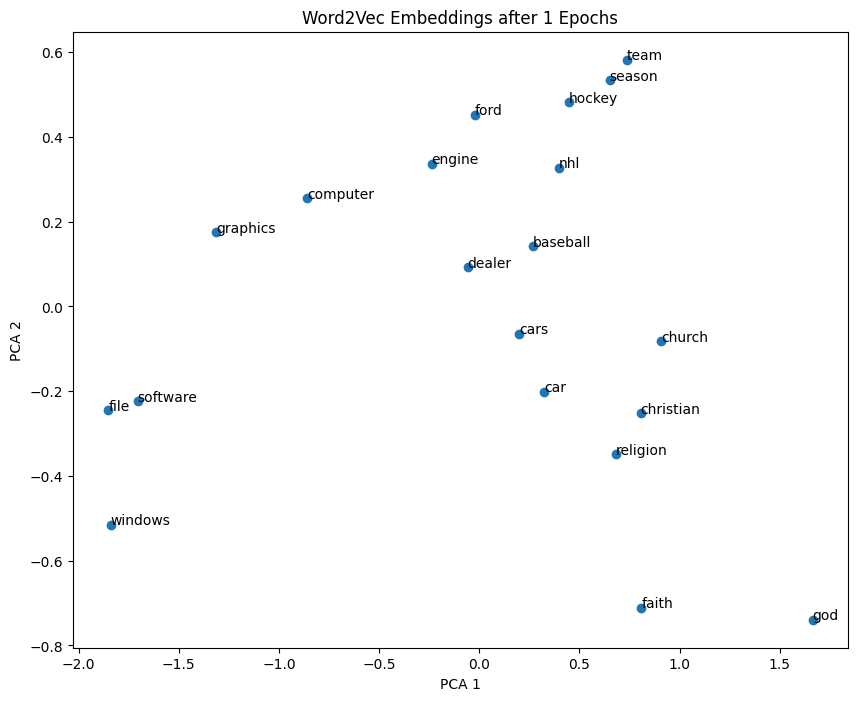

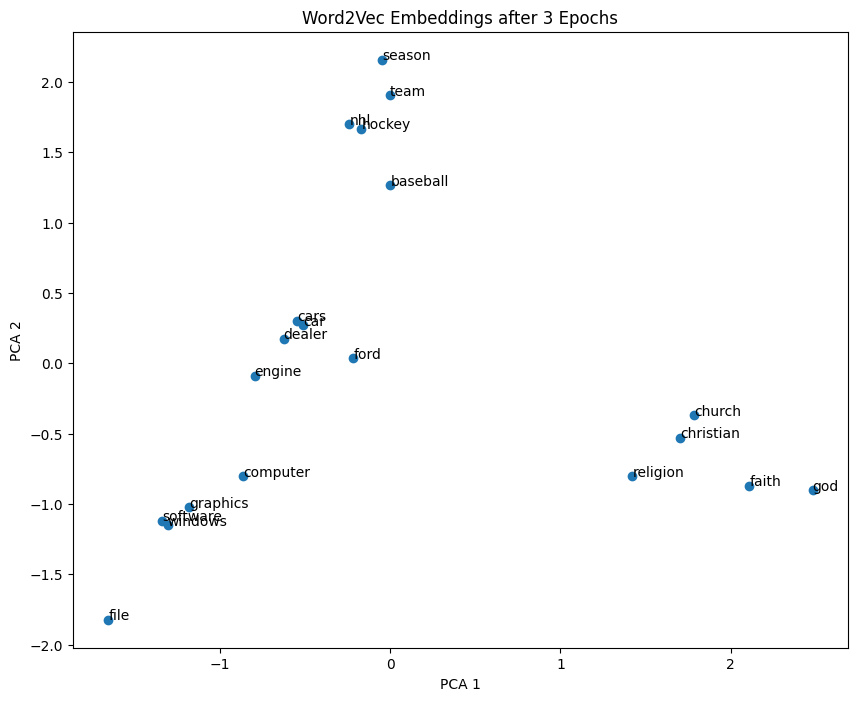

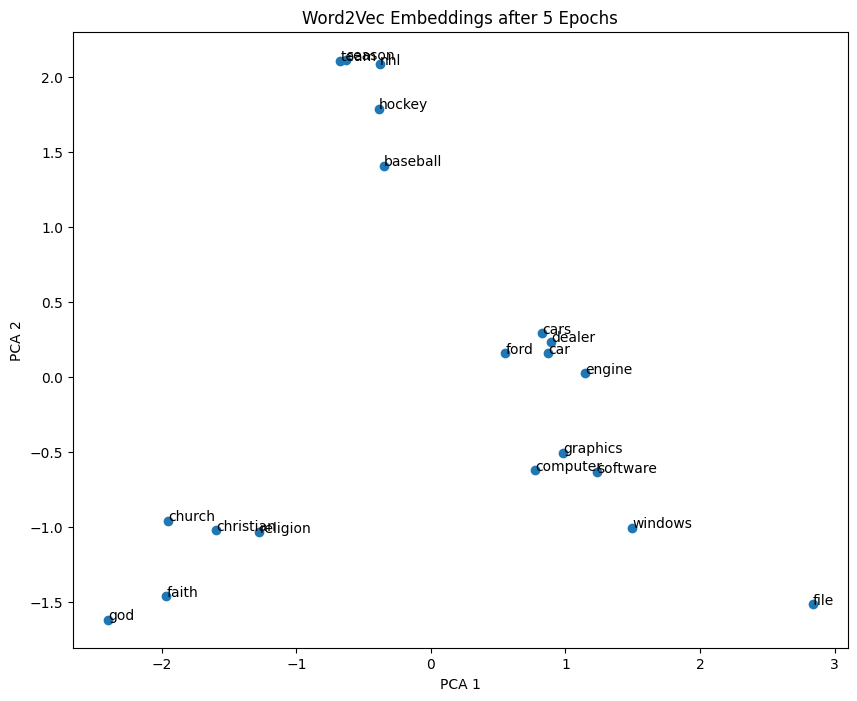

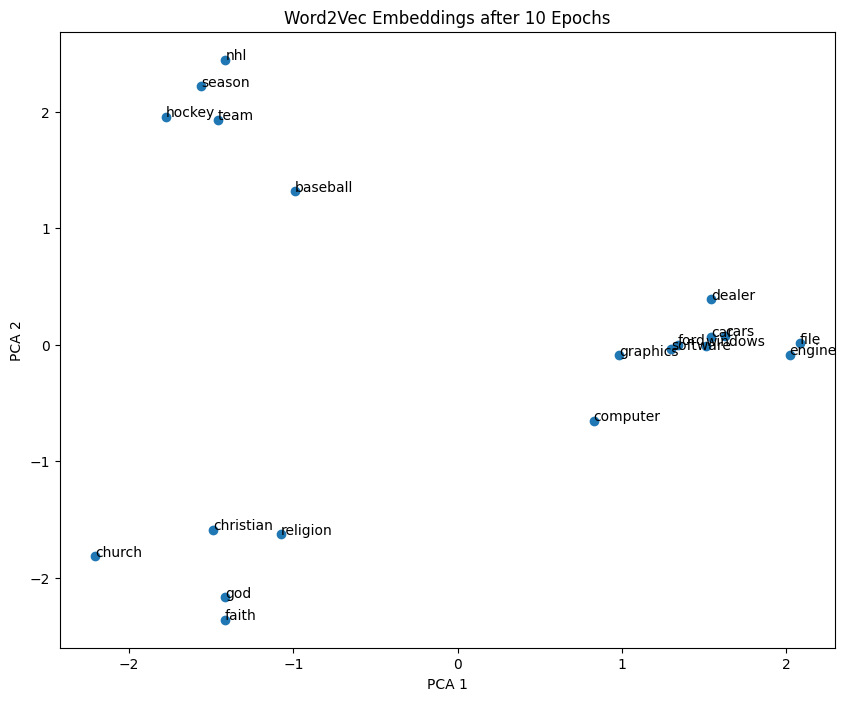

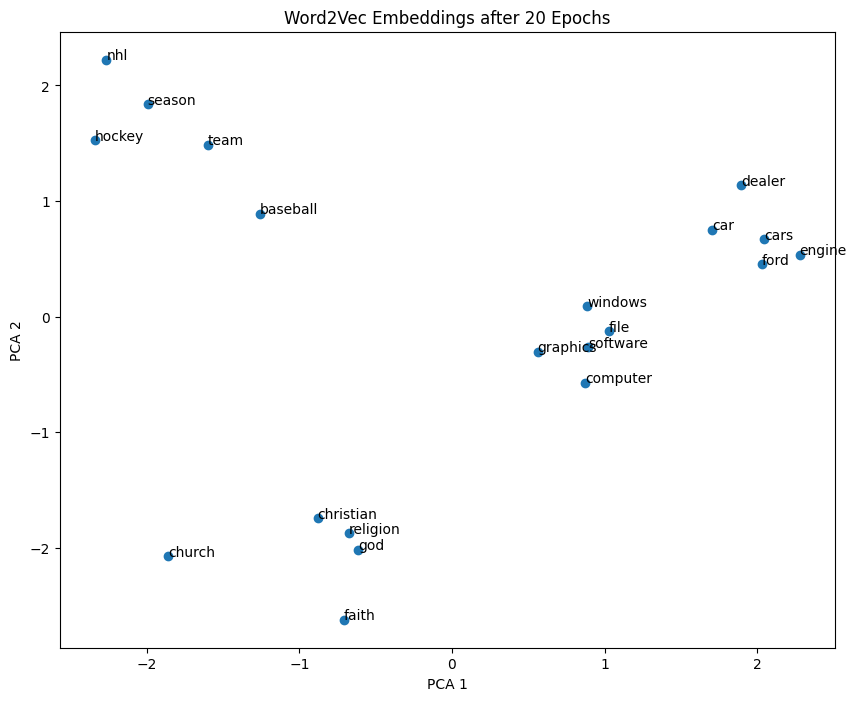

In [ ]:
for epoch_count, model in word2vec_models.items():
    wandb.init(
        project="nalapro-project",
        name=f"word2vec_visualization_{epoch_count}_epochs"
    )

    plot_word_vectors(
        model,
        words_to_plot,
        f"Word2Vec Embeddings after {epoch_count} Epochs"
    )

    wandb.finish()

In [ ]:
# Function to compute document vectors by averaging word vectors

def document_vector(model, doc_tokens):
    word_vectors = [model.wv[word] for word in doc_tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(word_vectors, axis=0)

In [ ]:
X_train_vectors = {}
X_test_vectors = {}

for epoch_count, model in word2vec_models.items():
    X_train_vectors[epoch_count] = np.array([
        document_vector(model, doc) for doc in X_train_tokens
    ])

    X_test_vectors[epoch_count] = np.array([
        document_vector(model, doc) for doc in X_test_tokens
    ])

    print(f"Epoch {epoch_count}:")
    print("Train shape:", X_train_vectors[epoch_count].shape)
    print("Test shape:", X_test_vectors[epoch_count].shape)
    print()

Epoch 1:
Train shape: (11314, 100)
Test shape: (7532, 100)

Epoch 3:
Train shape: (11314, 100)
Test shape: (7532, 100)

Epoch 5:
Train shape: (11314, 100)
Test shape: (7532, 100)

Epoch 10:
Train shape: (11314, 100)
Test shape: (7532, 100)

Epoch 20:
Train shape: (11314, 100)
Test shape: (7532, 100)



In [ ]:
# Converting labels to PyTorch tensors

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

### Neural Network

In [ ]:
# Defining a simple feedforward neural network with two linear layers and a ReLU in between for classification

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [ ]:
# Training function for the neural network
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_loss
        })

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

In [ ]:
# Evaluation function to compute accuracy on the test set

def evaluate_model(model, test_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return accuracy, precision, recall, f1

In [ ]:
word2vec_nn_results = {}

for epoch_count in word2vec_models.keys():

    wandb.init(
        project="nalapro-project",
        name=f"word2vec_nn_{epoch_count}_epochs",
        config={
            "experiment_type": "Word2Vec + SimpleNN",
            "word2vec_epochs": epoch_count,
            "input_dim": 100,
            "hidden_dim": 64,
            "output_dim": 20,
            "nn_epochs": 10,
            "batch_size": 32,
            "optimizer": "Adam",
            "learning_rate": 0.001
        }
    )

    X_train_tensor = torch.tensor(X_train_vectors[epoch_count], dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_vectors[epoch_count], dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model = SimpleNN(input_dim=100, hidden_dim=64, output_dim=20)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_model(model, train_loader, criterion, optimizer, epochs=10)

    accuracy, precision, recall, f1 = evaluate_model(model, test_loader)

    wandb.log({
        "test_accuracy": accuracy,
        "test_precision": precision,
        "test_recall": recall,
        "test_f1": f1
    })

    word2vec_nn_results[epoch_count] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    print(f"\nResults for Word2Vec {epoch_count} epochs:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    wandb.finish()

Epoch [1/10], Loss: 2.8416
Epoch [2/10], Loss: 2.5604
Epoch [3/10], Loss: 2.4814
Epoch [4/10], Loss: 2.4435
Epoch [5/10], Loss: 2.4136
Epoch [6/10], Loss: 2.3829
Epoch [7/10], Loss: 2.3527
Epoch [8/10], Loss: 2.3215
Epoch [9/10], Loss: 2.2945
Epoch [10/10], Loss: 2.2706

Results for Word2Vec 1 epochs:
Accuracy: 0.2643
Precision: 0.2424
Recall: 0.2643
F1-score: 0.2349


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▅▄▃▃▂▂▂▁▁
epoch,10
test_accuracy,0.26434
test_f1,0.2349
test_precision,0.24243
test_recall,0.26434


Epoch [1/10], Loss: 2.5432
Epoch [2/10], Loss: 1.9884
Epoch [3/10], Loss: 1.8378
Epoch [4/10], Loss: 1.7727
Epoch [5/10], Loss: 1.7337
Epoch [6/10], Loss: 1.7023
Epoch [7/10], Loss: 1.6776
Epoch [8/10], Loss: 1.6584
Epoch [9/10], Loss: 1.6393
Epoch [10/10], Loss: 1.6223

Results for Word2Vec 3 epochs:
Accuracy: 0.4530
Precision: 0.4452
Recall: 0.4530
F1-score: 0.4384


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
test_accuracy,0.453
test_f1,0.43836
test_precision,0.44522
test_recall,0.453


Epoch [1/10], Loss: 2.4774
Epoch [2/10], Loss: 1.8353
Epoch [3/10], Loss: 1.6552
Epoch [4/10], Loss: 1.5702
Epoch [5/10], Loss: 1.5180
Epoch [6/10], Loss: 1.4778
Epoch [7/10], Loss: 1.4470
Epoch [8/10], Loss: 1.4232
Epoch [9/10], Loss: 1.3996
Epoch [10/10], Loss: 1.3830

Results for Word2Vec 5 epochs:
Accuracy: 0.5305
Precision: 0.5283
Recall: 0.5305
F1-score: 0.5182


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
test_accuracy,0.53054
test_f1,0.51818
test_precision,0.52832
test_recall,0.53054


Epoch [1/10], Loss: 2.4351
Epoch [2/10], Loss: 1.7007
Epoch [3/10], Loss: 1.4724
Epoch [4/10], Loss: 1.3703
Epoch [5/10], Loss: 1.3059
Epoch [6/10], Loss: 1.2619
Epoch [7/10], Loss: 1.2291
Epoch [8/10], Loss: 1.2018
Epoch [9/10], Loss: 1.1794
Epoch [10/10], Loss: 1.1621

Results for Word2Vec 10 epochs:
Accuracy: 0.5976
Precision: 0.6027
Recall: 0.5976
F1-score: 0.5905


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
test_accuracy,0.59758
test_f1,0.5905
test_precision,0.60266
test_recall,0.59758


Epoch [1/10], Loss: 2.3415
Epoch [2/10], Loss: 1.5608
Epoch [3/10], Loss: 1.3481
Epoch [4/10], Loss: 1.2534
Epoch [5/10], Loss: 1.1935
Epoch [6/10], Loss: 1.1510
Epoch [7/10], Loss: 1.1182
Epoch [8/10], Loss: 1.0915
Epoch [9/10], Loss: 1.0721
Epoch [10/10], Loss: 1.0560

Results for Word2Vec 20 epochs:
Accuracy: 0.6261
Precision: 0.6343
Recall: 0.6261
F1-score: 0.6176


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
test_accuracy,0.62613
test_f1,0.61758
test_precision,0.63432
test_recall,0.62613


In [ ]:
# Creating a DataFrame to display the results in a tabular format

results_df = pd.DataFrame([
    {
        "Representation": f"Word2Vec ({epoch} epochs)",
        "NN Test Accuracy (%)": metrics["accuracy"] * 100,
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1-score": metrics["f1"]
    }
    for epoch, metrics in word2vec_nn_results.items()
])

results_df = results_df.sort_values(
    by="NN Test Accuracy (%)"
).reset_index(drop=True)

print(results_df)


wandb.init(
    project="nalapro-project",
    name="word2vec_results_summary"
)

wandb.log({
    "word2vec_results_table": wandb.Table(dataframe=results_df)
})

wandb.finish()

         Representation  NN Test Accuracy (%)  Precision    Recall  F1-score
0   Word2Vec (1 epochs)             26.433882   0.242426  0.264339  0.234896
1   Word2Vec (3 epochs)             45.300053   0.445219  0.453001  0.438357
2   Word2Vec (5 epochs)             53.053638   0.528323  0.530536  0.518179
3  Word2Vec (10 epochs)             59.758364   0.602657  0.597584  0.590504
4  Word2Vec (20 epochs)             62.612852   0.634325  0.626129  0.617582


## 1.c TF-IDF

In [ ]:
# Applying TF-IDF vectorization to the cleaned text data for comparison with Word2Vec embeddings

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (11314, 5000)
TF-IDF test shape: (7532, 5000)


In [ ]:
# Converting TF-IDF features to dense tensors for PyTorch

X_train_tfidf = X_train_tfidf.toarray()
X_test_tfidf = X_test_tfidf.toarray()

X_train_tensor_tfidf = torch.tensor(X_train_tfidf, dtype=torch.float32)
X_test_tensor_tfidf = torch.tensor(X_test_tfidf, dtype=torch.float32)

In [ ]:
# Creating datasets and loaders for TF-IDF features

train_dataset_tfidf = TensorDataset(X_train_tensor_tfidf, y_train_tensor)
test_dataset_tfidf = TensorDataset(X_test_tensor_tfidf, y_test_tensor)

train_loader_tfidf = DataLoader(train_dataset_tfidf, batch_size=64, shuffle=True)
test_loader_tfidf = DataLoader(test_dataset_tfidf, batch_size=64, shuffle=False)

In [ ]:
# Training the neural network on TF-IDF features for comparison

wandb.init(
    project="nalapro-project",
    name="tfidf_baseline",
    config={
        "experiment_type": "TF-IDF + SimpleNN",
        "max_features": 5000,
        "stop_words": "english",
        "input_dim": 5000,
        "hidden_dim": 128,
        "output_dim": 20,
        "batch_size": 64,
        "epochs": 10,
        "optimizer": "Adam",
        "learning_rate": 0.001
    }
)

input_dim = X_train_tfidf.shape[1]
hidden_dim = 128
output_dim = 20

model_tfidf = SimpleNN(input_dim, hidden_dim, output_dim)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tfidf.parameters(), lr=0.001)

train_model(model_tfidf, train_loader_tfidf, criterion, optimizer, epochs=10)

accuracy_tfidf, precision_tfidf, recall_tfidf, f1_tfidf = evaluate_model(
    model_tfidf,
    test_loader_tfidf
)


wandb.log({
    "test_accuracy": accuracy_tfidf,
    "test_precision": precision_tfidf,
    "test_recall": recall_tfidf,
    "test_f1": f1_tfidf
})

print(f"TF-IDF Accuracy: {accuracy_tfidf:.4f}")
print(f"TF-IDF Precision: {precision_tfidf:.4f}")
print(f"TF-IDF Recall: {recall_tfidf:.4f}")
print(f"TF-IDF F1-score: {f1_tfidf:.4f}")

wandb.finish()

Epoch [1/10], Loss: 2.5700
Epoch [2/10], Loss: 1.3742
Epoch [3/10], Loss: 0.8814
Epoch [4/10], Loss: 0.6501
Epoch [5/10], Loss: 0.5018
Epoch [6/10], Loss: 0.3970
Epoch [7/10], Loss: 0.3197
Epoch [8/10], Loss: 0.2637
Epoch [9/10], Loss: 0.2228
Epoch [10/10], Loss: 0.1936
TF-IDF Accuracy: 0.6423
TF-IDF Precision: 0.6555
TF-IDF Recall: 0.6423
TF-IDF F1-score: 0.6458


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
test_accuracy,0.64233
test_f1,0.64584
test_precision,0.65547
test_recall,0.64233


In [ ]:
# Storing the TF-IDF result for comparison

tf_idf_results = {
    "Representation": "TF-IDF",
    "NN Test Accuracy (%)": accuracy_tfidf * 100,
    "Precision": precision_tfidf,
    "Recall": recall_tfidf,
    "F1-score": f1_tfidf
}

tf_idf_results_df = pd.DataFrame([tf_idf_results])

results_df = pd.concat(
    [results_df, tf_idf_results_df],
    ignore_index=True
)

results_df = results_df.sort_values(
    by="NN Test Accuracy (%)"
).reset_index(drop=True)

results_df

,Representation,NN Test Accuracy (%),Precision,Recall,F1-score
0,Word2Vec (1 epochs),26.433882,0.242426,0.264339,0.234896
1,Word2Vec (3 epochs),45.300053,0.445219,0.453001,0.438357
2,Word2Vec (5 epochs),53.053638,0.528323,0.530536,0.518179
3,Word2Vec (10 epochs),59.758364,0.602657,0.597584,0.590504
4,Word2Vec (20 epochs),62.612852,0.634325,0.626129,0.617582
5,TF-IDF,64.232608,0.655468,0.642326,0.645839


## 1.d Extra Experiment - TF-IDF with N-Grams

In [ ]:
# Exploring TF-IDF with n-grams (unigrams + bigrams) to see if it improves performance

tfidf_ngram = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf_ngram = tfidf_ngram.fit_transform(X_train_clean)
X_test_tfidf_ngram = tfidf_ngram.transform(X_test_clean)

print("TF-IDF n-gram train shape:", X_train_tfidf_ngram.shape)
print("TF-IDF n-gram test shape:", X_test_tfidf_ngram.shape)

TF-IDF n-gram train shape: (11314, 10000)
TF-IDF n-gram test shape: (7532, 10000)


In [ ]:
# Converting TF-IDF n-gram features to dense tensors for PyTorch

X_train_tfidf_ngram = X_train_tfidf_ngram.toarray()
X_test_tfidf_ngram = X_test_tfidf_ngram.toarray()

X_train_tensor_ngram = torch.tensor(X_train_tfidf_ngram, dtype=torch.float32)
X_test_tensor_ngram = torch.tensor(X_test_tfidf_ngram, dtype=torch.float32)

train_dataset_ngram = TensorDataset(X_train_tensor_ngram, y_train_tensor)
test_dataset_ngram = TensorDataset(X_test_tensor_ngram, y_test_tensor)

train_loader_ngram = DataLoader(train_dataset_ngram, batch_size=64, shuffle=True)
test_loader_ngram = DataLoader(test_dataset_ngram, batch_size=64, shuffle=False)

In [ ]:
# Training the neural network on TF-IDF n-gram features for comparison

wandb.init(
    project="nalapro-project",
    name="tfidf_ngram_experiment",
    config={
        "experiment_type": "TF-IDF N-grams + SimpleNN",
        "max_features": 10000,
        "ngram_range": "(1, 2)",
        "stop_words": "english",
        "hidden_dim": 128,
        "output_dim": 20,
        "batch_size": 64,
        "epochs": 10,
        "optimizer": "Adam",
        "learning_rate": 0.001
    }
)

input_dim = X_train_tfidf_ngram.shape[1]
hidden_dim = 128
output_dim = 20

model_tfidf_ngram = SimpleNN(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tfidf_ngram.parameters(), lr=0.001)

train_model(model_tfidf_ngram, train_loader_ngram, criterion, optimizer, epochs=10)
accuracy_ngram, precision_ngram, recall_ngram, f1_ngram = evaluate_model(
    model_tfidf_ngram,
    test_loader_ngram
)

wandb.log({
    "test_accuracy": accuracy_ngram,
    "test_precision": precision_ngram,
    "test_recall": recall_ngram,
    "test_f1": f1_ngram
})

wandb.finish()

Epoch [1/10], Loss: 2.5421
Epoch [2/10], Loss: 1.2708
Epoch [3/10], Loss: 0.7345
Epoch [4/10], Loss: 0.4900
Epoch [5/10], Loss: 0.3435
Epoch [6/10], Loss: 0.2537
Epoch [7/10], Loss: 0.1987
Epoch [8/10], Loss: 0.1648
Epoch [9/10], Loss: 0.1438
Epoch [10/10], Loss: 0.1306


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▁▁▁▁▁
epoch,10
test_accuracy,0.66954
test_f1,0.67199
test_precision,0.68106
test_recall,0.66954


In [ ]:
# Storing the TF-IDF (1,2)-grams result for comparison

tf_idf_ngram_results = {
    "Representation": "TF-IDF (1,2)-grams",
    "NN Test Accuracy (%)": accuracy_ngram * 100,
    "Precision": precision_ngram,
    "Recall": recall_ngram,
    "F1-score": f1_ngram
}

tf_idf_ngram_results_df = pd.DataFrame([tf_idf_ngram_results])

results_df = pd.concat(
    [results_df, tf_idf_ngram_results_df],
    ignore_index=True
)

results_df = results_df.sort_values(
    by="NN Test Accuracy (%)"
).reset_index(drop=True)

results_df

,Representation,NN Test Accuracy (%),Precision,Recall,F1-score
0,Word2Vec (1 epochs),26.433882,0.242426,0.264339,0.234896
1,Word2Vec (3 epochs),45.300053,0.445219,0.453001,0.438357
2,Word2Vec (5 epochs),53.053638,0.528323,0.530536,0.518179
3,Word2Vec (10 epochs),59.758364,0.602657,0.597584,0.590504
4,Word2Vec (20 epochs),62.612852,0.634325,0.626129,0.617582
5,TF-IDF,64.232608,0.655468,0.642326,0.645839
6,"TF-IDF (1,2)-grams",66.954328,0.681062,0.669543,0.671990


## Testing Model after removing empty documents

In [ ]:
# Function to remove empty documents from the tokenized data and corresponding labels

def remove_empty_docs(X_tokens, X_clean, y):
    X_tokens_new = []
    X_clean_new = []
    y_new = []

    for tokens, clean_text, label in zip(X_tokens, X_clean, y):
        if len(tokens) > 0:
            X_tokens_new.append(tokens)
            X_clean_new.append(clean_text)
            y_new.append(label)

    return X_tokens_new, X_clean_new, y_new


X_train_tokens_noempty, X_train_clean_noempty, y_train_noempty = remove_empty_docs(
    X_train_tokens, X_train_clean, y_train
)

X_test_tokens_noempty, X_test_clean_noempty, y_test_noempty = remove_empty_docs(
    X_test_tokens, X_test_clean, y_test
)

print("Train size before:", len(X_train_tokens))
print("Train size after:", len(X_train_tokens_noempty))
print("Test size before:", len(X_test_tokens))
print("Test size after:", len(X_test_tokens_noempty))

Train size before: 11314
Train size after: 11000
Test size before: 7532
Test size after: 7302


In [ ]:
# Converting the labels of the non-empty documents to PyTorch tensors for potential use in training or evaluation

y_train_tensor_noempty = torch.tensor(y_train_noempty, dtype=torch.long)
y_test_tensor_noempty = torch.tensor(y_test_noempty, dtype=torch.long)

In [ ]:
# Helper function for no-empty experiments

def run_nn_experiment_wandb(
    X_train_vec,
    X_test_vec,
    y_train_tensor,
    y_test_tensor,
    run_name,
    representation_name,
    input_dim,
    hidden_dim=128,
    output_dim=20,
    batch_size=64,
    epochs=10,
    learning_rate=0.001
):
    wandb.init(
        project="nalapro-project",
        name=run_name,
        config={
            "experiment_type": representation_name,
            "preprocessing": "empty_documents_removed",
            "input_dim": input_dim,
            "hidden_dim": hidden_dim,
            "output_dim": output_dim,
            "batch_size": batch_size,
            "epochs": epochs,
            "optimizer": "Adam",
            "learning_rate": learning_rate
        }
    )

    X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_vec, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = SimpleNN(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_model(model, train_loader, criterion, optimizer, epochs=epochs)

    accuracy, precision, recall, f1 = evaluate_model(model, test_loader)

    wandb.log({
        "test_accuracy": accuracy,
        "test_precision": precision,
        "test_recall": recall,
        "test_f1": f1
    })

    wandb.finish()

    return {
        "Representation": representation_name,
        "NN Test Accuracy (%)": accuracy * 100,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [ ]:
# Creating Word2Vec document vectors after removing empty documents

X_train_vec_10_ne = np.array([
    document_vector(word2vec_models[10], doc)
    for doc in X_train_tokens_noempty
])

X_test_vec_10_ne = np.array([
    document_vector(word2vec_models[10], doc)
    for doc in X_test_tokens_noempty
])

X_train_vec_20_ne = np.array([
    document_vector(word2vec_models[20], doc)
    for doc in X_train_tokens_noempty
])

X_test_vec_20_ne = np.array([
    document_vector(word2vec_models[20], doc)
    for doc in X_test_tokens_noempty
])

In [ ]:
# Running no-empty Word2Vec experiments

noempty_results = []

noempty_results.append(
    run_nn_experiment_wandb(
        X_train_vec=X_train_vec_10_ne,
        X_test_vec=X_test_vec_10_ne,
        y_train_tensor=y_train_tensor_noempty,
        y_test_tensor=y_test_tensor_noempty,
        run_name="word2vec_10epochs_no_empty_docs",
        representation_name="Word2Vec (10 epochs) + no empty docs",
        input_dim=100
    )
)

noempty_results.append(
    run_nn_experiment_wandb(
        X_train_vec=X_train_vec_20_ne,
        X_test_vec=X_test_vec_20_ne,
        y_train_tensor=y_train_tensor_noempty,
        y_test_tensor=y_test_tensor_noempty,
        run_name="word2vec_20epochs_no_empty_docs",
        representation_name="Word2Vec (20 epochs) + no empty docs",
        input_dim=100
    )
)

Epoch [1/10], Loss: 2.4614
Epoch [2/10], Loss: 1.6851
Epoch [3/10], Loss: 1.4363
Epoch [4/10], Loss: 1.3184
Epoch [5/10], Loss: 1.2532
Epoch [6/10], Loss: 1.2079
Epoch [7/10], Loss: 1.1750
Epoch [8/10], Loss: 1.1467
Epoch [9/10], Loss: 1.1233
Epoch [10/10], Loss: 1.1068


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
test_accuracy,0.61243
test_f1,0.6017
test_precision,0.61286
test_recall,0.61243


Epoch [1/10], Loss: 2.4649
Epoch [2/10], Loss: 1.6098
Epoch [3/10], Loss: 1.3262
Epoch [4/10], Loss: 1.2046
Epoch [5/10], Loss: 1.1350
Epoch [6/10], Loss: 1.0881
Epoch [7/10], Loss: 1.0573
Epoch [8/10], Loss: 1.0295
Epoch [9/10], Loss: 1.0085
Epoch [10/10], Loss: 0.9917


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▁▁▁▁▁
epoch,10
test_accuracy,0.64202
test_f1,0.63157
test_precision,0.63694
test_recall,0.64202


In [ ]:
# Applying TF-IDF vectorization with n-grams to the non-empty cleaned text data for comparison with the original TF-IDF vectors that included empty documents

tfidf_ngram_noempty = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf_ne = tfidf_ngram_noempty.fit_transform(X_train_clean_noempty)
X_test_tfidf_ne = tfidf_ngram_noempty.transform(X_test_clean_noempty)

X_train_tfidf_ne = X_train_tfidf_ne.toarray()
X_test_tfidf_ne = X_test_tfidf_ne.toarray()

In [ ]:
# Running no-empty TF-IDF n-gram experiment

noempty_results.append(
    run_nn_experiment_wandb(
        X_train_vec=X_train_tfidf_ne,
        X_test_vec=X_test_tfidf_ne,
        y_train_tensor=y_train_tensor_noempty,
        y_test_tensor=y_test_tensor_noempty,
        run_name="tfidf_ngrams_no_empty_docs",
        representation_name="TF-IDF (1,2)-grams + no empty docs",
        input_dim=X_train_tfidf_ne.shape[1]
    )
)

Epoch [1/10], Loss: 2.5325
Epoch [2/10], Loss: 1.2211
Epoch [3/10], Loss: 0.6755
Epoch [4/10], Loss: 0.4258
Epoch [5/10], Loss: 0.2760
Epoch [6/10], Loss: 0.1822
Epoch [7/10], Loss: 0.1243
Epoch [8/10], Loss: 0.0881
Epoch [9/10], Loss: 0.0655
Epoch [10/10], Loss: 0.0507


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
train_loss,█▄▃▂▂▁▁▁▁▁
epoch,10
test_accuracy,0.68748
test_f1,0.68702
test_precision,0.68971
test_recall,0.68748


In [ ]:
# Creating clean comparison table

results_noempty_df = pd.DataFrame(noempty_results)

combined_df = pd.concat(
    [results_df, results_noempty_df],
    ignore_index=True
)

combined_df = combined_df.sort_values(
    by="NN Test Accuracy (%)"
).reset_index(drop=True)

combined_df

,Representation,NN Test Accuracy (%),Precision,Recall,F1-score
0,Word2Vec (1 epochs),26.433882,0.242426,0.264339,0.234896
1,Word2Vec (3 epochs),45.300053,0.445219,0.453001,0.438357
2,Word2Vec (5 epochs),53.053638,0.528323,0.530536,0.518179
3,Word2Vec (10 epochs),59.758364,0.602657,0.597584,0.590504
4,Word2Vec (10 epochs) + no empty docs,61.243495,0.612858,0.612435,0.601704
5,Word2Vec (20 epochs),62.612852,0.634325,0.626129,0.617582
6,Word2Vec (20 epochs) + no empty docs,64.201589,0.636937,0.642016,0.631574
7,TF-IDF,64.232608,0.655468,0.642326,0.645839
8,"TF-IDF (1,2)-grams",66.954328,0.681062,0.669543,0.671990
9,"TF-IDF (1,2)-grams + no empty docs",68.734593,0.690036,0.687346,0.687053


# Task 2: BERT Fine-Tuning

In [ ]:
train_data = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

test_data = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)

X_train = train_data.data
y_train = train_data.target

X_test = test_data.data
y_test = test_data.target

label_names = train_data.target_names

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Number of classes:", len(label_names))
print("Class names:", label_names)

Training samples: 11314
Test samples: 7532
Number of classes: 20
Class names: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [ ]:
empty_train = sum(1 for doc in X_train if len(doc.strip()) == 0)
empty_test = sum(1 for doc in X_test if len(doc.strip()) == 0)

print("Empty training documents:", empty_train)
print("Empty test documents:", empty_test)

Empty training documents: 300
Empty test documents: 215


In [ ]:
train_df = pd.DataFrame({"text": X_train, "label": y_train})
test_df = pd.DataFrame({"text": X_test, "label": y_test})

train_df = train_df[train_df["text"].str.strip() != ""].reset_index(drop=True)
test_df = test_df[test_df["text"].str.strip() != ""].reset_index(drop=True)

print("Filtered training samples:", len(train_df))
print("Filtered test samples:", len(test_df))

Filtered training samples: 11014
Filtered test samples: 7317


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"].tolist()
)

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 9912
Validation size: 1102
Test size: 7317


In [ ]:
wandb.init(
    project="nalapro-project",
    name="bert_base_finetune",
    config={
        "experiment_type": "BERT fine-tuning",
        "model": "bert-base-uncased",
        "dataset": "20 Newsgroups",
        "empty_documents_removed": True,
        "num_classes": 20,
        "max_length": 64,
        "epochs": 3,
        "batch_size": 16,
        "learning_rate": 2e-5,
        "weight_decay": 0.01
    }
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
train_dataset = Dataset.from_dict({
    "text": train_texts,
    "label": train_labels
})

val_dataset = Dataset.from_dict({
    "text": val_texts,
    "label": val_labels
})

test_dataset = Dataset.from_dict({
    "text": test_texts,
    "label": test_labels
})

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/9912 [00:00<?, ? examples/s]

Map:   0%|          | 0/1102 [00:00<?, ? examples/s]

Map:   0%|          | 0/7317 [00:00<?, ? examples/s]

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=20
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="wandb",
    run_name="bert_base_finetune"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.454431,0.958007,0.724138,0.730392,0.724138,0.720206


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.454431,0.958007,0.724138,0.730392,0.724138,0.720206
2,0.670970,0.846293,0.744102,0.730683,0.744102,0.734418
3,0.411617,0.873569,0.751361,0.750298,0.751361,0.748286


TrainOutput(global_step=3717, training_loss=0.8456727469964858, metrics={'train_runtime': 1492.2619, 'train_samples_per_second': 19.927, 'train_steps_per_second': 2.491, 'total_flos': 3912567397466112.0, 'train_loss': 0.8456727469964858, 'epoch': 3.0})

In [ ]:
bert_test_results = trainer.evaluate(eval_dataset=test_dataset)

bert_test_results

{'eval_loss': 1.0022603273391724,
 'eval_accuracy': 0.7328139948066147,
 'eval_precision': 0.7299260825652334,
 'eval_recall': 0.7328139948066147,
 'eval_f1': 0.7288501874496858,
 'eval_runtime': 120.0647,
 'eval_samples_per_second': 60.942,
 'eval_steps_per_second': 7.621,
 'epoch': 3.0}

In [ ]:
test_predictions = trainer.predict(test_dataset)
y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = np.array(test_labels)

In [ ]:
test_accuracy = accuracy_score(y_true, y_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("BERT Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("BERT Test Precision:", round(test_precision, 4))
print("BERT Test Recall:", round(test_recall, 4))
print("BERT Test F1:", round(test_f1, 4))

In [ ]:
wandb.log({
    "test_accuracy": bert_test_results["eval_accuracy"],
    "test_precision": bert_test_results["eval_precision"],
    "test_recall": bert_test_results["eval_recall"],
    "test_f1": bert_test_results["eval_f1"]
})

wandb.finish()

In [ ]:
bert_result_row = {
    "Representation": "BERT base fine-tuned",
    "NN Test Accuracy (%)": test_accuracy * 100,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1
}

combined_df = pd.concat(
    [combined_df, pd.DataFrame([bert_result_row])],
    ignore_index=True
)

combined_df = combined_df.drop_duplicates(
    subset=["Model"],
    keep="last"
).reset_index(drop=True)

combined_df = combined_df.sort_values(
    by="NN Test Accuracy (%)"
).reset_index(drop=True)

combined_df

,Representation,NN Test Accuracy (%),Precision,Recall,F1-score
0,Word2Vec (1 epochs),26.433882,0.242426,0.264339,0.234896
1,Word2Vec (3 epochs),45.300053,0.445219,0.453001,0.438357
2,Word2Vec (5 epochs),53.053638,0.528323,0.530536,0.518179
3,Word2Vec (10 epochs),59.758364,0.602657,0.597584,0.590504
4,Word2Vec (10 epochs) + no empty docs,61.243495,0.612858,0.612435,0.601704
5,Word2Vec (20 epochs),62.612852,0.634325,0.626129,0.617582
6,Word2Vec (20 epochs) + no empty docs,64.201589,0.636937,0.642016,0.631574
7,TF-IDF,64.232608,0.655468,0.642326,0.645839
8,"TF-IDF (1,2)-grams",66.954328,0.681062,0.669543,0.671990
9,"TF-IDF (1,2)-grams + no empty docs",68.734593,0.690036,0.687346,0.687053


                          precision    recall  f1-score   support

             alt.atheism       0.49      0.53      0.51       311
           comp.graphics       0.69      0.73      0.71       384
 comp.os.ms-windows.misc       0.68      0.71      0.69       379
comp.sys.ibm.pc.hardware       0.69      0.67      0.68       386
   comp.sys.mac.hardware       0.74      0.73      0.73       371
          comp.windows.x       0.82      0.80      0.81       391
            misc.forsale       0.85      0.84      0.84       382
               rec.autos       0.84      0.79      0.81       375
         rec.motorcycles       0.81      0.73      0.76       386
      rec.sport.baseball       0.90      0.86      0.88       383
        rec.sport.hockey       0.88      0.90      0.89       390
               sci.crypt       0.74      0.76      0.75       380
         sci.electronics       0.65      0.65      0.65       383
                 sci.med       0.85      0.88      0.86       382
         

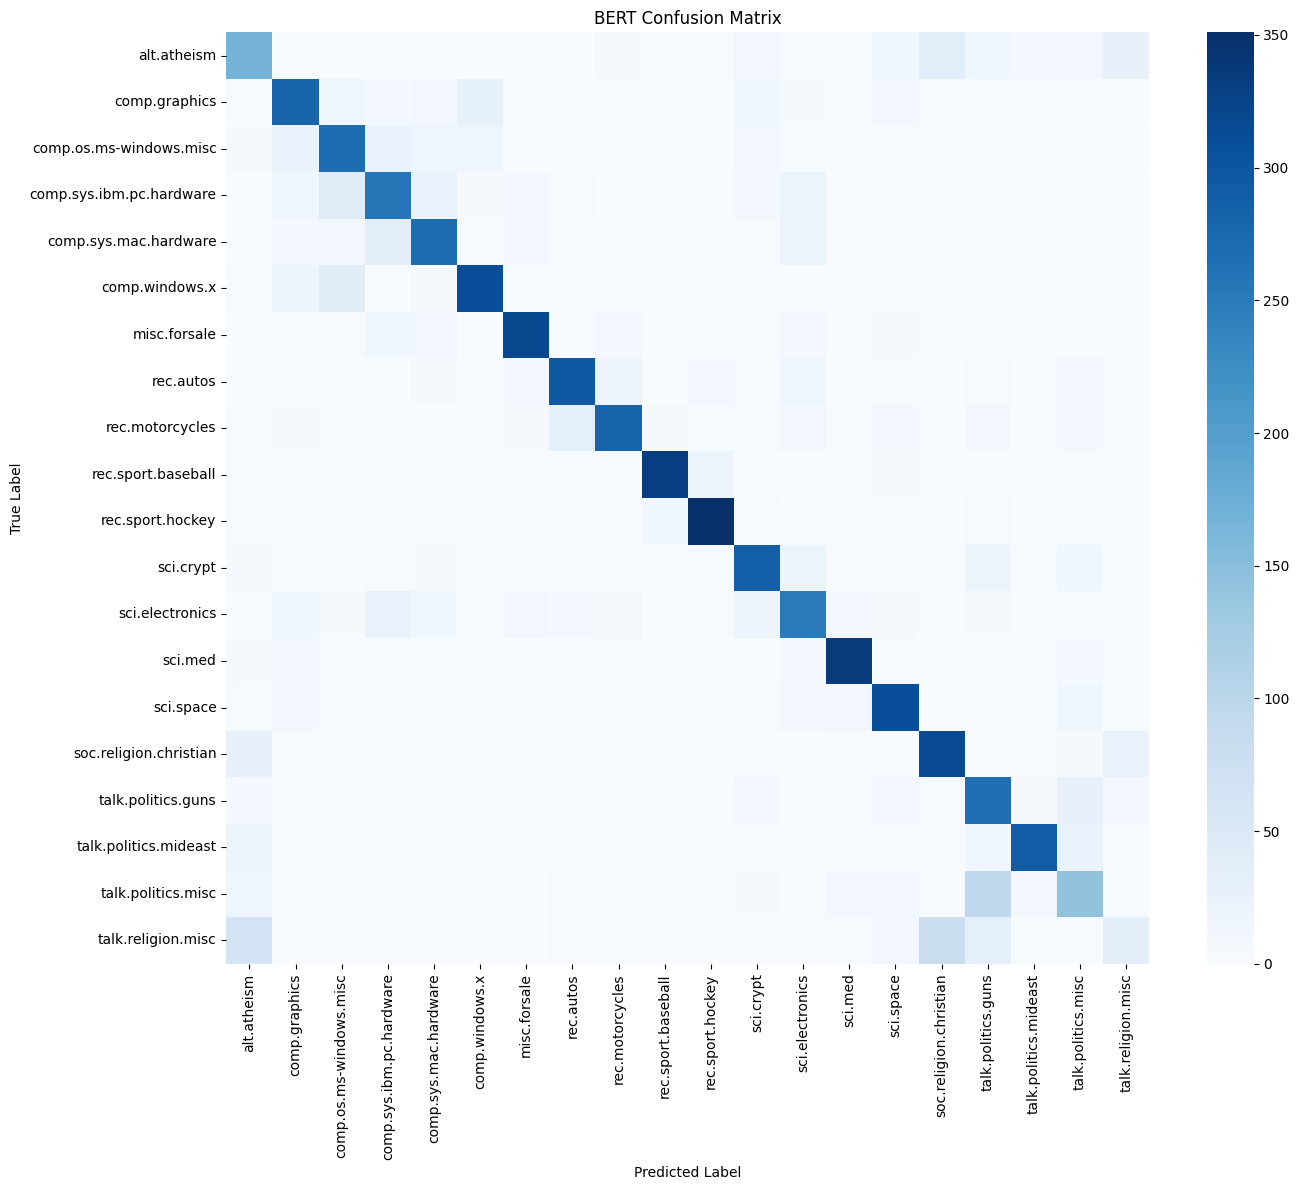

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    annot=False,
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
bert_results_df = pd.DataFrame([{
    "Model": "BERT-base fine-tuned",
    "Test Accuracy (%)": round(test_accuracy * 100, 2),
    "Test Precision": round(test_precision, 4),
    "Test Recall": round(test_recall, 4),
    "Test F1": round(test_f1, 4)
}])

bert_results_df.to_csv("bert_task2_results.csv", index=False)
bert_results_df

,Model,Test Accuracy (%),Test Precision,Test Recall,Test F1
0,BERT-base fine-tuned,73.28,0.7299,0.7328,0.7289


## Experiments

In [ ]:
def run_bert_experiment(model_name="bert-base-uncased",
                        learning_rate=2e-5,
                        epochs=3,
                        batch_size=8,
                        max_length=128):

    run_name = f"bert_lr{learning_rate}_ep{epochs}_bs{batch_size}_len{max_length}"

    wandb.init(
        project="nalapro-project",
        name=run_name,
        config={
            "experiment_type": "BERT hyperparameter experiment",
            "model": model_name,
            "learning_rate": learning_rate,
            "epochs": epochs,
            "batch_size": batch_size,
            "max_length": max_length,
            "num_classes": 20,
            "empty_documents_removed": True
        }
    )

    tokenizer = BertTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=max_length
        )

    train_ds = Dataset.from_dict({"text": train_texts, "label": train_labels})
    val_ds = Dataset.from_dict({"text": val_texts, "label": val_labels})
    test_ds = Dataset.from_dict({"text": test_texts, "label": test_labels})

    train_ds = train_ds.map(tokenize_function, batched=True)
    val_ds = val_ds.map(tokenize_function, batched=True)
    test_ds = test_ds.map(tokenize_function, batched=True)

    train_ds = train_ds.rename_column("label", "labels")
    val_ds = val_ds.rename_column("label", "labels")
    test_ds = test_ds.rename_column("label", "labels")

    train_ds = train_ds.remove_columns(["text"])
    val_ds = val_ds.remove_columns(["text"])
    test_ds = test_ds.remove_columns(["text"])

    train_ds.set_format("torch")
    val_ds.set_format("torch")
    test_ds.set_format("torch")

    model = BertForSequenceClassification.from_pretrained(
        model_name,
        num_labels=20
    )

    training_args = TrainingArguments(
        output_dir=f"./bert_experiment_results/{run_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="wandb",
        run_name=run_name
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()

    predictions = trainer.predict(test_ds)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = np.array(test_labels)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    wandb.log({
        "test_accuracy": acc,
        "test_precision": prec,
        "test_recall": rec,
        "test_f1": f1
    })

    wandb.finish()

    return {
        "model": model_name,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "batch_size": batch_size,
        "max_length": max_length,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

In [ ]:
experiments = [
    run_bert_experiment(
        learning_rate=2e-5,
        epochs=3,
        batch_size=8,
        max_length=128
    ),

    run_bert_experiment(
        learning_rate=3e-5,
        epochs=3,
        batch_size=8,
        max_length=128
    ),

    run_bert_experiment(
        learning_rate=2e-5,
        epochs=2,
        batch_size=8,
        max_length=256
    ),

    run_bert_experiment(
        learning_rate=3e-5,
        epochs=2,
        batch_size=8,
        max_length=256
    )
]

bert_experiment_results = pd.DataFrame(experiments)

bert_experiment_results = bert_experiment_results.sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

bert_experiment_results.to_csv("bert_experiment_results.csv", index=False)

bert_experiment_results

Map:   0%|          | 0/9912 [00:00<?, ? examples/s]

Map:   0%|          | 0/1102 [00:00<?, ? examples/s]

Map:   0%|          | 0/7317 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

eval/accuracy,▁█
eval/f1,▁█
eval/loss,█▁
eval/precision,▁█
eval/recall,▁█
eval/runtime,█▁
eval/samples_per_second,▁█
eval/steps_per_second,▁█
test/accuracy,▁
test/f1,▁
+15,...


,model,learning_rate,epochs,batch_size,max_length,accuracy,precision,recall,f1
0,bert-base-uncased,0.00003,2,8,256,0.728714,0.729061,0.728714,0.725339
1,bert-base-uncased,0.00003,3,8,128,0.720514,0.717947,0.720514,0.717168
2,bert-base-uncased,0.00002,3,8,128,0.718327,0.716427,0.718327,0.715363
3,bert-base-uncased,0.00002,2,8,256,0.718737,0.707584,0.718737,0.710439


In [ ]:
bert_experiment_results.to_csv("bert_experiment_results.csv", index=False)

# Saving Files to Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

drive_output_dir = "/content/drive/MyDrive/NALAPRO_Final_Project/outputs"
os.makedirs(drive_output_dir, exist_ok=True)

In [ ]:
import shutil

files_to_copy = [
    "bert_task2_results.csv",
    "bert_experiment_results.csv",
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, drive_output_dir)
        print("Copied:", file)
    else:
        print("Missing:", file)

Copied: bert_task2_results.csv
Copied: bert_experiment_results.csv


In [ ]:
plt.savefig("bert_confusion_matrix.png", dpi=200, bbox_inches="tight")

shutil.copy("bert_confusion_matrix.png", drive_output_dir)

'/content/drive/MyDrive/NALAPRO_Final_Project/outputs/bert_confusion_matrix.png'

<Figure size 640x480 with 0 Axes>